In [185]:
import pandas as pd
from spacy.lang.en import English
import numpy as np
import spacy
import re

import sklearn
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('COD7_Steam_Review.csv', header=None, names=["language", "review"])

In [4]:
df.head()

,language,review
0,english,mid\n
1,english,Call of Duty is officially at its worst. I ref...
2,english,"bad campaign, decent multiplayer, good zombies..."
3,english,Campaign - BO3 levels of bad \nMultiplayer - D...
4,english,Zombies is so ass I hit a trashcan and the gam...


In [5]:
review = df['review']

In [6]:
review.head()

,review
0,mid\n
1,Call of Duty is officially at its worst. I ref...
2,"bad campaign, decent multiplayer, good zombies..."
3,Campaign - BO3 levels of bad \nMultiplayer - D...
4,Zombies is so ass I hit a trashcan and the gam...


In [7]:
#check for null
for e in review.isnull():
  if e == True:
    print(e)

In [8]:
import random
import torch
from transformers import BertTokenizer, BertModel

In [9]:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(2244)

In [10]:
# NOT USED
# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

encoding = tokenizer.batch_encode_plus(review,# List of input texts
    padding=True,              # Pad to the maximum sequence length
    truncation=True,           # Truncate to the maximum sequence length if necessary
    return_tensors='pt',      # Return PyTorch tensors
    add_special_tokens=True    # Add special tokens CLS and SEP
)

input_ids = encoding['input_ids']            # Token IDs
attention_mask = encoding['attention_mask']  # Attention mask

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [11]:
#Remove [PAD] from decoded output
tokenizer.add_special_tokens({'pad_token' : "[PAD]"})

0

In [12]:
#BERT TEST UNSUSED
encoded_r = []
for i in review:
	encoded_r.append(tokenizer.encode(i, padding='max_length', max_length = 512, truncation=True))

In [199]:
nlp = English()

#Text cleaning
my_doc = []
for r in review:
  clean = re.sub(r'[^a-zA-Z0-9]', ' ', r)
  doc = nlp(clean)
  my_doc.append(doc)

In [200]:
#Remove Stop Word
filtered_words = []
for doc in my_doc:
  filtered_words.append([token.text for token in doc if not token.is_stop])

text = ''
final_text = []
for words in filtered_words:
  for word in words:
    text += word + ' '
  final_text.append(text)
  text = ''

In [290]:
#Vectorization
vectorizer = TfidfVectorizer()
vectors = vectorizer.fit_transform(final_text)

In [289]:
#DBSCAN implementation
dbscan = DBSCAN(eps=1, min_samples=15)
dbscan.fit(vectors)

DBSCAN(eps=1, min_samples=15)

In [288]:
cluster_labels = dbscan.labels_
coords = vectors.toarray()

In [291]:
no_clusters = len(np.unique(cluster_labels))
no_noise = np.sum(np.array(cluster_labels) == -1, axis=0)

print('Estimated no. of clusters: %d' % no_clusters)
print('Estimated no. of noise points: %d' % no_noise)

Estimated no. of clusters: 2
Estimated no. of noise points: 244


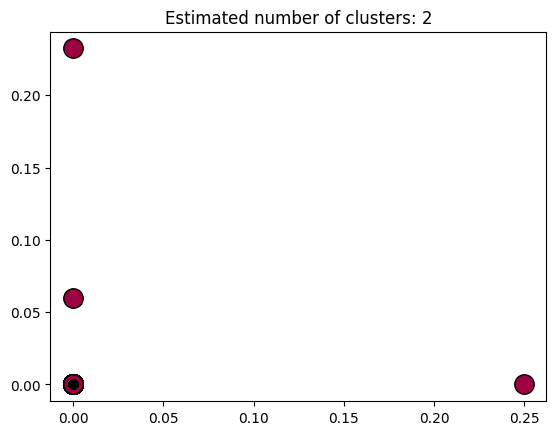

In [292]:
#source: https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html
#used code provided on scikit learn to create the plot
unique_labels = set(cluster_labels)
core_samples_mask = np.zeros_like(cluster_labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = cluster_labels == k

    xy = coords[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = coords[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {no_clusters}")
plt.show()

In [277]:
df_clustered = pd.DataFrame({'review': review, 'cluster': cluster_labels})
df_clustered

,review,cluster
0,mid\n,0
1,Call of Duty is officially at its worst. I ref...,0
2,"bad campaign, decent multiplayer, good zombies...",0
3,Campaign - BO3 levels of bad \nMultiplayer - D...,0
4,Zombies is so ass I hit a trashcan and the gam...,-1
...,...,...
1271,First review :D,0
1272,black slop 7,0
1273,It's here!,0
1274,Great,0


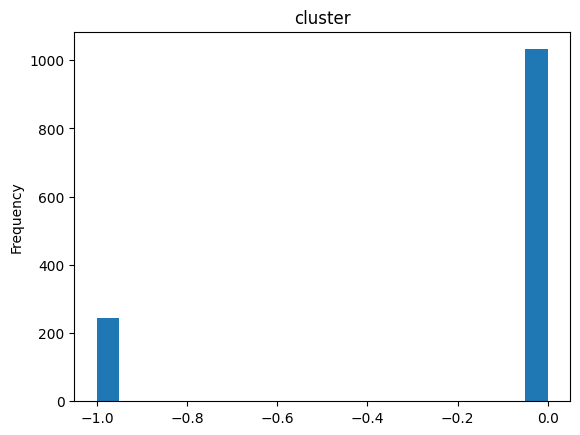

In [278]:
df_clustered['cluster'].plot(kind='hist', bins=20, title='cluster')
plt.show()

In [280]:
from sklearn.cluster import HDBSCAN

In [285]:
hdb = HDBSCAN(min_cluster_size=18)
hdb.fit(vectors)

print(np.unique(hdb.labels_).tolist())

unq_labels = np.unique(hdb.labels_).tolist()

labels = hdb.labels_
no_clusters = len(np.unique(labels))
no_noise = np.sum(np.array(labels) == -1, axis=0)

print('Estimated no. of clusters: %d' % no_clusters)
print('Estimated no. of noise points: %d' % no_noise)

[-1, 0, 1]
Estimated no. of clusters: 3
Estimated no. of noise points: 1024


In [286]:
hdb_cluster = pd.DataFrame({'review': review, 'cluster': labels})
hdb_cluster

,review,cluster
0,mid\n,0
1,Call of Duty is officially at its worst. I ref...,-1
2,"bad campaign, decent multiplayer, good zombies...",0
3,Campaign - BO3 levels of bad \nMultiplayer - D...,-1
4,Zombies is so ass I hit a trashcan and the gam...,-1
...,...,...
1271,First review :D,1
1272,black slop 7,0
1273,It's here!,0
1274,Great,1


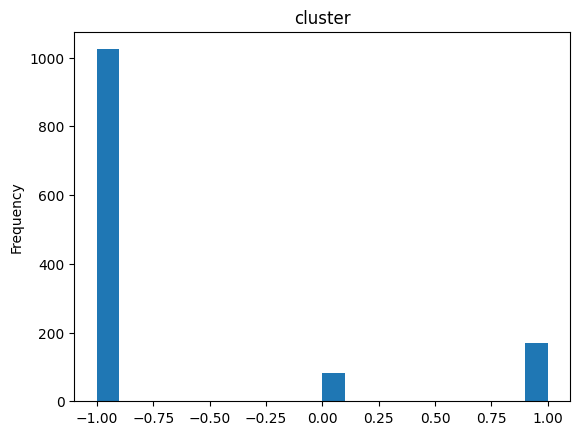

In [283]:
hdb_cluster['cluster'].plot(kind='hist', bins=20, title='cluster')
plt.show()

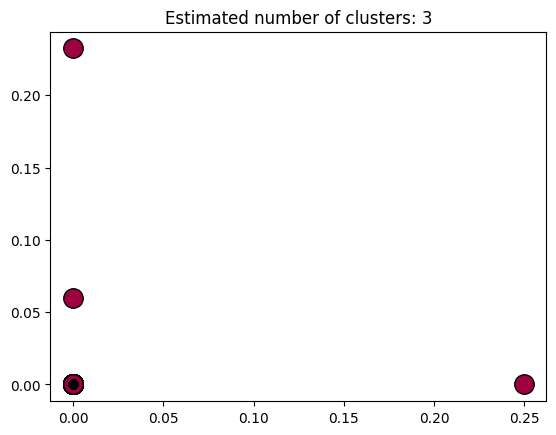

In [287]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = cluster_labels == k

    xy = coords[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = coords[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {no_clusters}")
plt.show()